## Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots



# Display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## Load the Supplier Dataset

In [2]:
# File path
file_path = "/dsa/groups/casestudycf25/team02/silver/dmepos_suplr_serv_clean.csv"

# Read CSV
df = pd.read_csv(file_path)

# Preview dataset
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1454474, 33)


,year,suplr_npi,suplr_prvdr_last_name_org,suplr_prvdr_first_name,suplr_prvdr_mi,suplr_prvdr_crdntls,suplr_prvdr_ent_cd,suplr_prvdr_st1,suplr_prvdr_st2,suplr_prvdr_city,suplr_prvdr_state_abrvtn,suplr_prvdr_state_fips,suplr_prvdr_zip5,suplr_prvdr_ruca_cat,suplr_prvdr_ruca,suplr_prvdr_ruca_desc,suplr_prvdr_cntry,suplr_prvdr_spclty_cd,suplr_prvdr_spclty_desc,suplr_prvdr_spclty_srce,rbcs_lvl,rbcs_id,rbcs_desc,hcpcs_cd,hcpcs_desc,suplr_rentl_ind,tot_suplr_benes,tot_suplr_clms,tot_suplr_srvcs,avg_suplr_sbmtd_chrg,avg_suplr_mdcr_alowd_amt,avg_suplr_mdcr_pymt_amt,avg_suplr_mdcr_stdzd_amt
0,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,18,46032,Urban,1.0,Metropolitan area core: primary flow within an...,US,02,general_surgery,Claim-Specialty,Orthotic Devices,DF000N,DME-Orthotic Devices,L3808,"Wrist hand finger orthosis, rigid without join...",N,69.0,79,82,435.609756,325.202683,257.561707,262.395732
1,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,18,46032,Urban,1.0,Metropolitan area core: primary flow within an...,US,02,general_surgery,Claim-Specialty,Orthotic Devices,DF000N,DME-Orthotic Devices,L3906,"Wrist hand orthosis, without joints, may inclu...",N,30.0,30,35,448.285714,439.852857,351.134286,315.416286
2,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,18,46032,Urban,1.0,Metropolitan area core: primary flow within an...,US,02,general_surgery,Claim-Specialty,Orthotic Devices,DF000N,DME-Orthotic Devices,L3908,"Wrist hand orthosis, wrist extension control c...",N,84.0,99,107,108.457944,66.980000,51.914953,46.384393
3,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,18,46032,Urban,1.0,Metropolitan area core: primary flow within an...,US,02,general_surgery,Claim-Specialty,Orthotic Devices,DF000N,DME-Orthotic Devices,L3913,"Hand finger orthosis, without joints, may incl...",N,16.0,16,16,348.000000,247.410000,197.133125,191.759375
4,2021,1003000399,"Reconstructive Hand To Shoulder Of Indiana, Llc",NaN,NaN,NaN,O,13431 Old Meridian Street,Suite 225,Carmel,IN,18,46032,Urban,1.0,Metropolitan area core: primary flow within an...,US,02,general_surgery,Claim-Specialty,Orthotic Devices,DF000N,DME-Orthotic Devices,L3923,"Hand finger orthosis, without joints, may incl...",N,54.0,59,66,113.030303,88.250000,66.411515,65.491667


## Inspect Columns

In [3]:
print("Columns in dataset:")
print(df.columns)

Columns in dataset:
Index(['year', 'suplr_npi', 'suplr_prvdr_last_name_org',
       'suplr_prvdr_first_name', 'suplr_prvdr_mi', 'suplr_prvdr_crdntls',
       'suplr_prvdr_ent_cd', 'suplr_prvdr_st1', 'suplr_prvdr_st2',
       'suplr_prvdr_city', 'suplr_prvdr_state_abrvtn',
       'suplr_prvdr_state_fips', 'suplr_prvdr_zip5', 'suplr_prvdr_ruca_cat',
       'suplr_prvdr_ruca', 'suplr_prvdr_ruca_desc', 'suplr_prvdr_cntry',
       'suplr_prvdr_spclty_cd', 'suplr_prvdr_spclty_desc',
       'suplr_prvdr_spclty_srce', 'rbcs_lvl', 'rbcs_id', 'rbcs_desc',
       'hcpcs_cd', 'hcpcs_desc', 'suplr_rentl_ind', 'tot_suplr_benes',
       'tot_suplr_clms', 'tot_suplr_srvcs', 'avg_suplr_sbmtd_chrg',
       'avg_suplr_mdcr_alowd_amt', 'avg_suplr_mdcr_pymt_amt',
       'avg_suplr_mdcr_stdzd_amt'],
      dtype='object')


## Define Missouri + Surrounding States

In [4]:
state_col = "suplr_prvdr_state_abrvtn"
supplier_col = "suplr_npi"

states_of_interest = [
    "MO",  # Missouri
    "IA",  # Iowa
    "IL",  # Illinois
    "KY",  # Kentucky
    "TN",  # Tennessee
    "AR",  # Arkansas
    "KS",  # Kansas
    "OK",  # Oklahoma
    "NE"   # Nebraska
]

In [5]:
print("Unique state values (sample):")
print(df[state_col].dropna().unique()[:20])

Unique state values (sample):
['IN' 'TN' 'NJ' 'ME' 'PA' 'CT' 'IL' 'SC' 'FL' 'OK' 'KY' 'MD' 'TX' 'MS'
 'OR' 'CO' 'MO' 'WA' 'VA' 'CA']


## Filter Dataset for Selected States

In [6]:
df_states = df[df[state_col].isin(states_of_interest)]

print("Filtered dataset shape:", df_states.shape)

Filtered dataset shape: (277334, 33)


In [7]:
top_supplier_data = (
    df_states
    .groupby([
        "suplr_npi",
        "suplr_prvdr_last_name_org",
        "suplr_prvdr_state_abrvtn",
        "suplr_prvdr_ruca_cat"
    ])
    .size()
    .reset_index(name="claim_count")
)

In [8]:
top10 = (
    top_supplier_data
    .sort_values("claim_count", ascending=False)
    .head(10)
)

In [9]:
color_map = {
    "Urban": "red",
    "Rural": "blue"
}

colors = top10["suplr_prvdr_ruca_cat"].map(color_map)

## Top 10 Suppliers Overall

In [10]:
top_suppliers = (
    df_states
    .groupby(supplier_col)
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(top_suppliers)

suplr_npi
1053366740    529
1053400960    469
1336111053    468
1669417531    457
1811997638    395
1144371204    359
1326042342    342
1376916379    341
1396700621    338
1528069309    337
dtype: int64


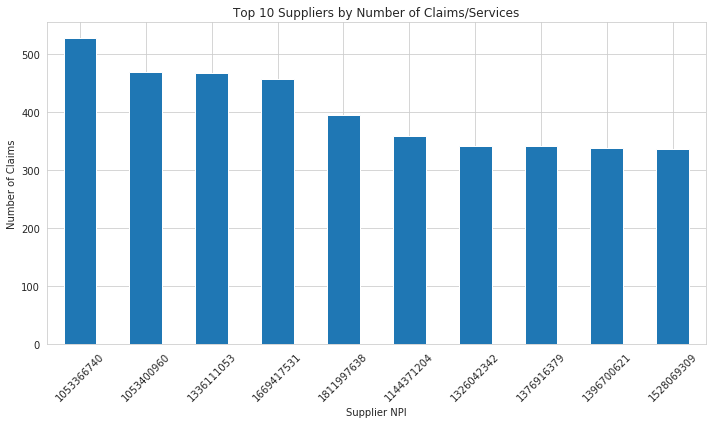

In [11]:
plt.figure(figsize=(10,6))

top_suppliers.plot(kind="bar")

plt.title("Top 10 Suppliers by Number of Claims/Services")
plt.xlabel("Supplier NPI")
plt.ylabel("Number of Claims")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Bar Charts for Missouri and Border states

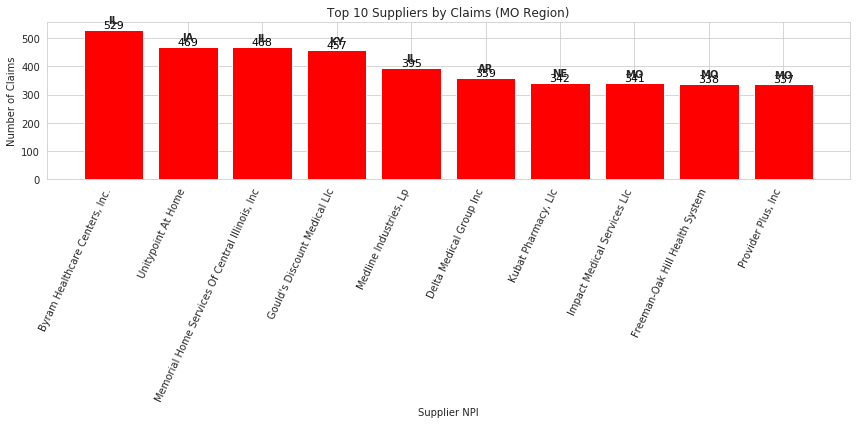

In [12]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    top10["suplr_prvdr_last_name_org"].astype(str),
    top10["claim_count"],
    color=colors
)

plt.title("Top 10 Suppliers by Claims (MO Region)")
plt.xlabel("Supplier NPI")
plt.ylabel("Number of Claims")

plt.xticks(rotation=65, ha="right")

# Add claim count labels
for bar, count in zip(bars, top10["claim_count"]):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(count),
        ha='center',
        va='bottom',
        color='black',
        fontsize=11
    )

# Add STATE labels above bars
for bar, state in zip(bars, top10["suplr_prvdr_state_abrvtn"]):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 15,
        state,
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

## Using NPI

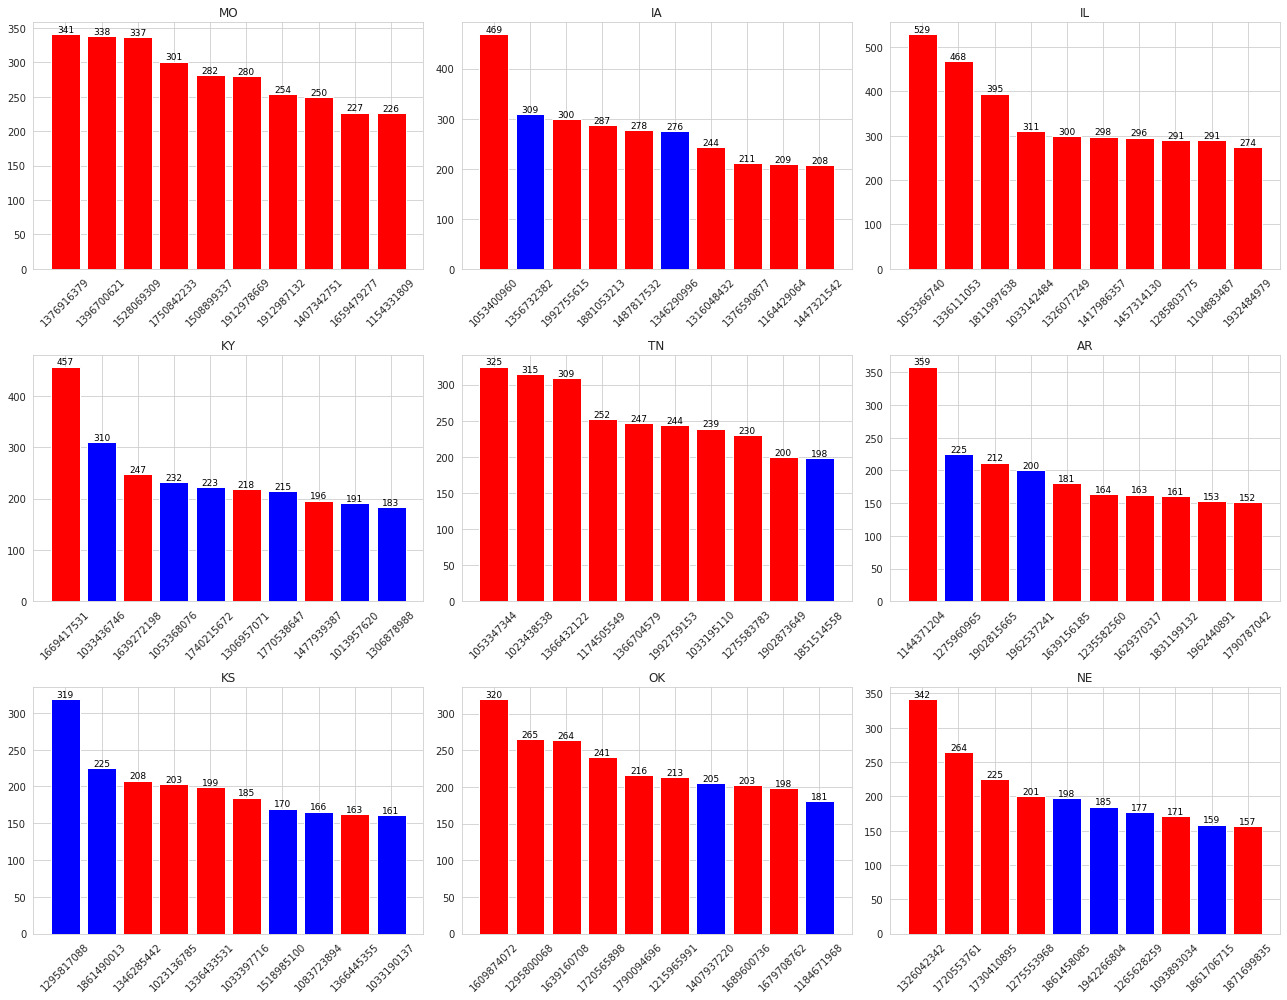

In [13]:
fig, axes = plt.subplots(3,3, figsize=(18,14))

axes = axes.flatten()

for i, state in enumerate(states_of_interest):

    df_state = df_states[df_states[state_col] == state]

    top_state = (
        df_state
        .groupby(["suplr_npi","suplr_prvdr_ruca_cat"])
        .size()
        .reset_index(name="claim_count")
        .sort_values("claim_count", ascending=False)
        .head(10)
    )

    colors = top_state["suplr_prvdr_ruca_cat"].map(color_map)

    bars = axes[i].bar(
        top_state["suplr_npi"].astype(str),
        top_state["claim_count"],
        color=colors
    )

    axes[i].set_title(state)
    axes[i].tick_params(axis='x', rotation=45)

    # Add count labels
    for bar, count in zip(bars, top_state["claim_count"]):

        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            str(count),
            ha='center',
            va='bottom',
            fontsize=9,
            color='black'
        )

plt.tight_layout()
plt.show()

## Using Names

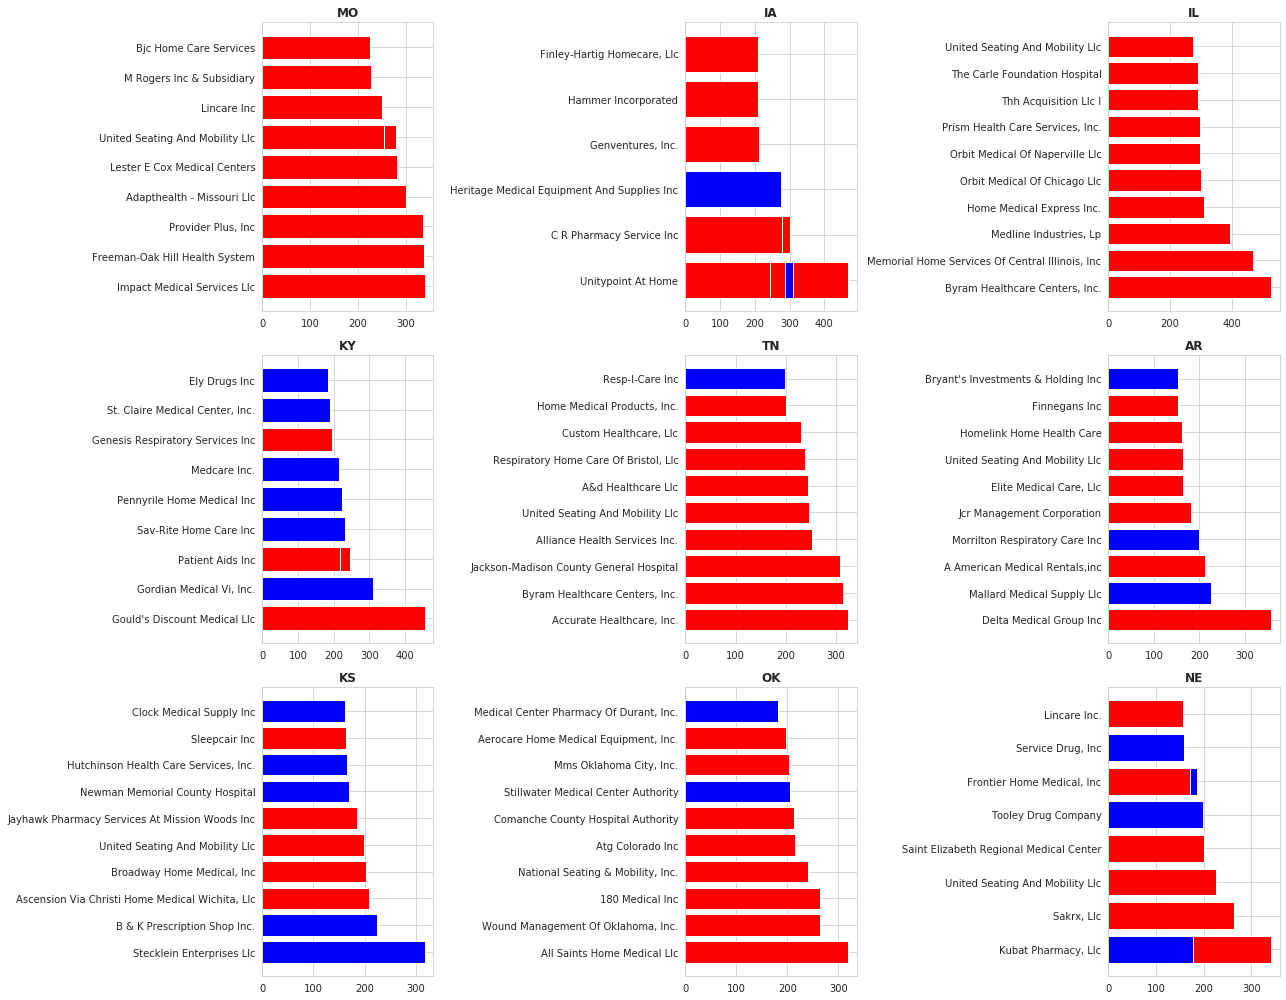

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, state in enumerate(states_of_interest):
    # Data filtering and processing
    df_state = df_states[df_states[state_col] == state]

    top_state = (
        df_state
        .groupby("suplr_npi")
        .size()
        .reset_index(name="claim_count")
        .sort_values("claim_count", ascending=False)
        .head(10)
    )
    
    top_state = top_state.merge(
        df_state[["suplr_npi", "suplr_prvdr_last_name_org", "suplr_prvdr_ruca_cat"]],
        on="suplr_npi",
        how="left"
    ).drop_duplicates("suplr_npi")

    colors = top_state["suplr_prvdr_ruca_cat"].map(color_map)

    # Plotting on the current axis
    bars = axes[i].barh(
        top_state["suplr_prvdr_last_name_org"],
        top_state["claim_count"],
        color=colors
    )

    # --- EVERYTHING BELOW IS NOW INSIDE THE LOOP ---
    axes[i].set_title(f"State: {state}", fontsize=12, fontweight='bold')
    axes[i].invert_yaxis()  # Keeps the #1 supplier at the top
    
    # Add numbers on bars for THIS specific chart
    for bar, count in zip(bars, top_state["claim_count"]):
        axes[i].text(
            bar.get_width() + (bar.get_width() * 0.01), # Add slight padding
            bar.get_y() + bar.get_height()/2,
            str(count),
            va='center',
            fontsize=9,
            color="black"
        )
        axes[i].set_title(state, fontweight='bold')
        axes[i].invert_yaxis()

# Optional: Hide labels on inner charts to reduce clutter
plt.tight_layout()
plt.show()


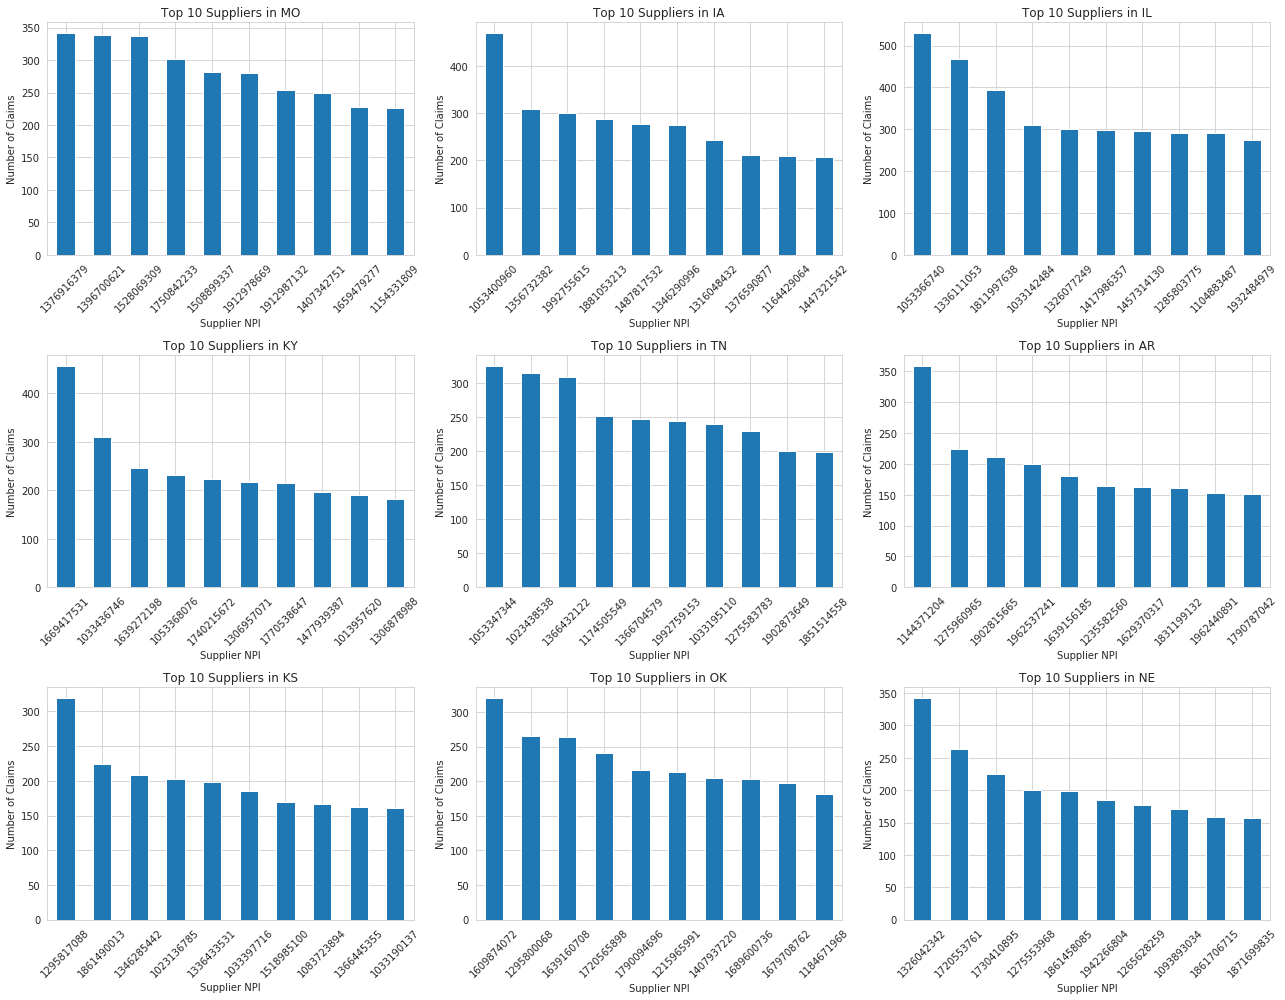

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

# Ensure i is an integer index (0-8) and state is the value
for i, state in enumerate(states_of_interest):
    
    df_state = df_states[df_states[state_col] == state]

    top_state_suppliers = (
        df_state
        .groupby(supplier_col)
        .size()
        .sort_values(ascending=False)
        .head(10)
    )

    # Use the 'ax' parameter to plot on the specific subplot
    top_state_suppliers.plot(kind="bar", ax=axes[i])

    axes[i].set_title(f"Top 10 Suppliers in {state}")
    axes[i].set_xlabel("Supplier NPI")
    axes[i].set_ylabel("Number of Claims")
    axes[i].tick_params(axis='x', rotation=45)

# Adjust layout once at the end
plt.tight_layout()
plt.show()
